In [1]:
# ============================================================
# CELL 1 — Load and inspect the unicorn dataset
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

# Load unicorn dataset
uf = pd.read_csv('../data/raw/unicorns.csv', encoding='latin1')

print(f"Shape: {uf.shape[0]} rows x {uf.shape[1]} columns")
print(f"\nColumn names:")
print(uf.columns.tolist())
print(f"\nFirst 3 rows:")
uf.head(3)

Shape: 102 rows x 8 columns

Column names:
['No.', 'Company', 'Sector', 'Entry Valuation^^ ($B)', 'Valuation ($B)', 'Entry', 'Location', 'Select Investors']

First 3 rows:


,No.,Company,Sector,Entry Valuation^^ ($B),Valuation ($B),Entry,Location,Select Investors
0,1,InMobi,Adtech - Mobile Ads,1.0,1.0,Sep/2011,Bangalore/Singapore,"KPCB, Sherpalo Ventures, SoftBank"
1,2,Flipkart^,E-Commerce,1.0,37.6,Feb/2012,Bangalore/Singapore,"Accel, Tiger Global, Naspers, SoftBank, Tencent"
2,3,Mu Sigma,SaaS - Analytics,1.0,1.5,Feb/2013,Bangalore/Chicago,"Accel, Sequoia Capital, General Atlantic"


In [2]:
# ============================================================
# CELL 2 — Clean the unicorn dataset
# Rename columns and extract year from entry date
# ============================================================

# Rename columns
uf.columns = ['no', 'company', 'sector', 'entry_valuation_b', 'valuation_b', 'entry_date', 'location', 'investors']

# Extract year from "Sep/2011" format
uf['unicorn_year'] = uf['entry_date'].str.split('/').str[-1].astype(int)

# Drop no column
uf.drop(columns=['no'], inplace=True)

print("Unicorns per year:")
print(uf['unicorn_year'].value_counts().sort_index())

Unicorns per year:
unicorn_year
2011     1
2012     1
2013     1
2014     1
2015     4
2016     2
2018     8
2019     9
2020    10
2021    44
2022    21
Name: count, dtype: int64


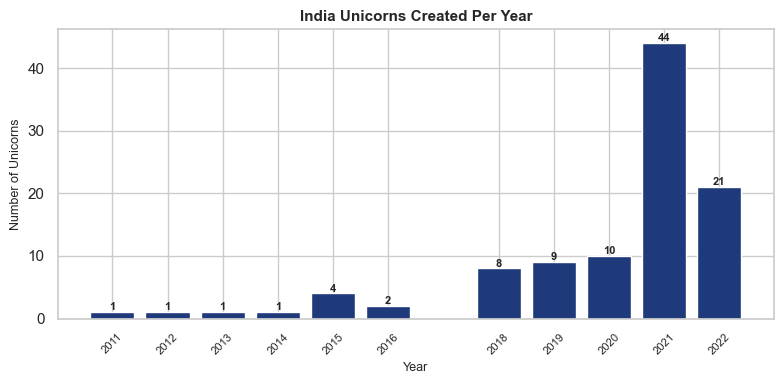

In [3]:
# ============================================================
# CELL 3 — Unicorns created per year
# Bar chart showing India's unicorn growth over time
# ============================================================

unicorns_per_year = uf['unicorn_year'].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(unicorns_per_year.index, unicorns_per_year.values, color='#1F3A7A')
plt.title('India Unicorns Created Per Year', fontsize=11, fontweight='bold')
plt.xlabel('Year', fontsize=9)
plt.ylabel('Number of Unicorns', fontsize=9)
plt.xticks(unicorns_per_year.index, rotation=45, fontsize=8)

# Add value labels
for x, y in zip(unicorns_per_year.index, unicorns_per_year.values):
    plt.text(x, y + 0.3, str(y), ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/chart_unicorns_per_year.png', dpi=150)
plt.show()

Top sectors by unicorn count:
sector
Edtech                          5
E-Commerce                      4
Logistics Services              4
Marketplace - Used Cars         4
Gaming                          3
SaaS - CRM                      2
E-Commerce - Social Commerce    2
E-Commerce - Groceries          2
Foodtech                        2
Fintech - General Insurance     2
Name: count, dtype: int64


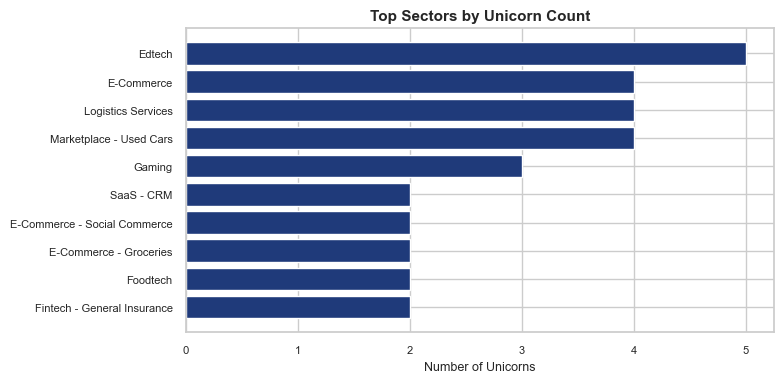

In [4]:
# ============================================================
# CELL 4 — Which sectors produce the most unicorns
# ============================================================

sector_unicorns = uf['sector'].value_counts().head(10)

print("Top sectors by unicorn count:")
print(sector_unicorns)

plt.figure(figsize=(8, 4))
plt.barh(sector_unicorns.index[::-1], sector_unicorns.values[::-1], color='#1F3A7A')
plt.title('Top Sectors by Unicorn Count', fontsize=11, fontweight='bold')
plt.xlabel('Number of Unicorns', fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_unicorn_sectors.png', dpi=150)
plt.show()

Top 10 unicorns by valuation ($B):
      company  valuation_b
1   Flipkart^         37.6
10      BYJUS         22.0
4      PayTM^         16.0
33   PhonePe^         12.0
12     Swiggy         10.7
85    Polygon         10.0
15  OYO Rooms          9.6
21    Dream11          8.0
31   RazorPay          7.5
5    Ola Cabs          7.3


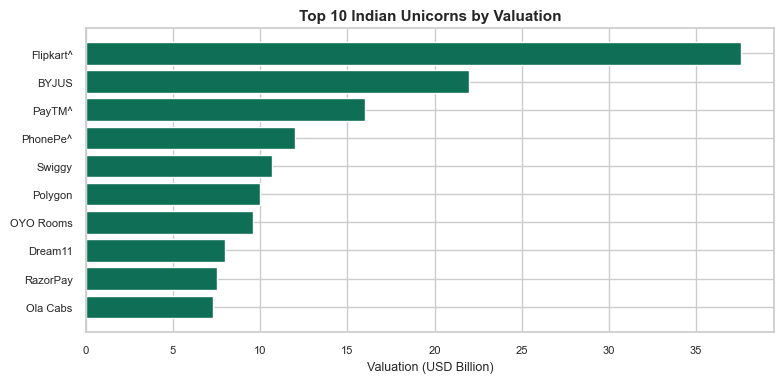

In [5]:
# ============================================================
# CELL 5 — Top 10 unicorns by current valuation
# ============================================================

top_unicorns = uf.nlargest(10, 'valuation_b')[['company', 'valuation_b']]

print("Top 10 unicorns by valuation ($B):")
print(top_unicorns)

plt.figure(figsize=(8, 4))
plt.barh(top_unicorns['company'][::-1], top_unicorns['valuation_b'][::-1], color='#0F6E56')
plt.title('Top 10 Indian Unicorns by Valuation', fontsize=11, fontweight='bold')
plt.xlabel('Valuation (USD Billion)', fontsize=9)
plt.tick_params(axis='both', labelsize=8)
plt.tight_layout()

plt.savefig('../reports/chart_top_unicorns.png', dpi=150)
plt.show()

Correlation matrix:
                   entry_valuation_b  valuation_b  unicorn_year
entry_valuation_b               1.00         0.22          0.10
valuation_b                     0.22         1.00         -0.44
unicorn_year                    0.10        -0.44          1.00


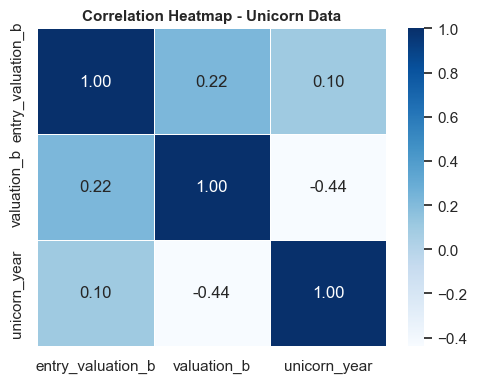

In [6]:
# ============================================================
# CELL 6 — Fix company names and correlation heatmap
# Strip special characters from company names
# Then check correlation between valuation and unicorn year
# ============================================================

# Fix company names
uf['company'] = uf['company'].str.replace('^', '', regex=False)
uf['company'] = uf['company'].str.replace('*', '', regex=False)
uf['company'] = uf['company'].str.strip()

# Correlation between numeric columns
corr = uf[['entry_valuation_b', 'valuation_b', 'unicorn_year']].corr()

print("Correlation matrix:")
print(corr.round(2))

plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Correlation Heatmap - Unicorn Data', fontsize=11, fontweight='bold')
plt.tight_layout()

plt.savefig('../reports/chart_correlation_heatmap.png', dpi=150)
plt.show()

In [7]:
# ============================================================
# CELL 7 — SQL queries using sqlite3
# Load cleaned data into SQLite and run business queries
# ============================================================

import sqlite3

# Load cleaned funding data
df = pd.read_csv('../data/cleaned/startup_funding_cleaned.csv')

# Create in-memory SQLite database
conn = sqlite3.connect(':memory:')
df.to_sql('funding', conn, index=False, if_exists='replace')
uf.to_sql('unicorns', conn, index=False, if_exists='replace')

print("Database ready.")
print("=" * 50)

# Query 1 — Top 5 most funded startups
q1 = pd.read_sql("""
    SELECT startup_name, SUM(amount_usd) as total_funding
    FROM funding
    GROUP BY startup_name
    ORDER BY total_funding DESC
    LIMIT 5
""", conn)
print("Top 5 Most Funded Startups:")
print(q1)
print()

# Query 2 — Top 5 cities by average deal size
q2 = pd.read_sql("""
    SELECT city, ROUND(AVG(amount_usd), 2) as avg_funding
    FROM funding
    WHERE city != 'Unknown'
    GROUP BY city
    ORDER BY avg_funding DESC
    LIMIT 5
""", conn)
print("Top 5 Cities by Average Deal Size:")
print(q2)
print()

# Query 3 — Total funding by investment type
q3 = pd.read_sql("""
    SELECT investment_type, 
           COUNT(*) as deals,
           ROUND(SUM(amount_usd), 2) as total_funding
    FROM funding
    GROUP BY investment_type
    ORDER BY total_funding DESC
    LIMIT 5
""", conn)
print("Top Investment Types by Total Funding:")
print(q3)
print()

# Query 4 — Top 5 sectors by unicorn count
q4 = pd.read_sql("""
    SELECT sector, COUNT(*) as unicorn_count
    FROM unicorns
    GROUP BY sector
    ORDER BY unicorn_count DESC
    LIMIT 5
""", conn)
print("Top 5 Sectors by Unicorn Count:")
print(q4)

Database ready.
Top 5 Most Funded Startups:
       startup_name  total_funding
0          Flipkart   4.059700e+09
1  Rapido Bike Taxi   3.900000e+09
2             Paytm   3.148950e+09
3               Ola   9.845000e+08
4             Udaan   8.700000e+08

Top 5 Cities by Average Deal Size:
              city  avg_funding
0       Menlo Park  450000000.0
1       California  300000000.0
2  India/Singapore  226000000.0
3         Tulangan  200000000.0
4       Kormangala  142000000.0

Top Investment Types by Total Funding:
  investment_type  deals  total_funding
0  Private Equity   1074   2.729715e+10
1        Series B     20   4.799196e+09
2        Series D     12   1.481799e+09
3         Venture      5   1.164500e+09
4        Series C     14   1.044718e+09

Top 5 Sectors by Unicorn Count:
                    sector  unicorn_count
0                   Edtech              5
1  Marketplace - Used Cars              4
2       Logistics Services              4
3               E-Commerce           